In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
)

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("Mall_Customers (1).csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

df.describe()

(200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

df.isnull().sum()

Shape after removing duplicates: (200, 5)


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

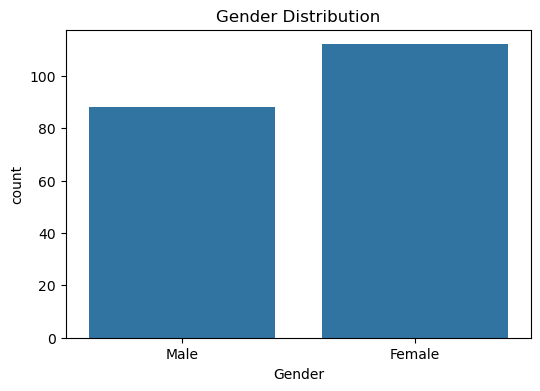

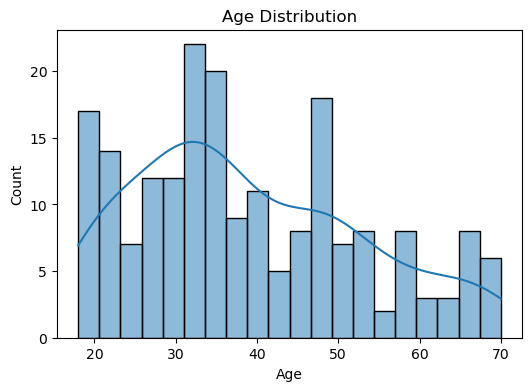

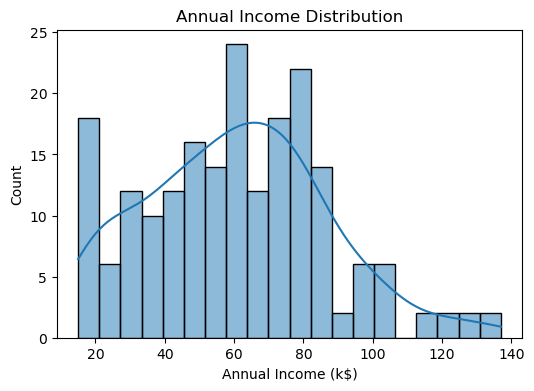

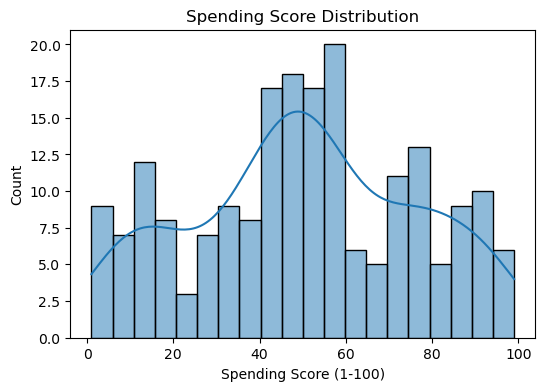

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

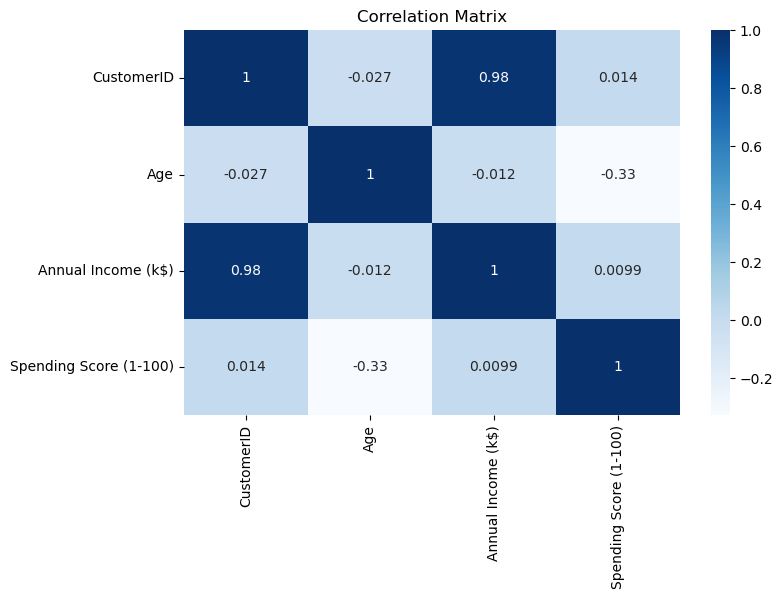

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [11]:
df["HighSpender"] = np.where(
    df["Spending Score (1-100)"] >= 50,
    1,
    0
)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),HighSpender
0,1,Male,19,15,39,0
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,0


In [12]:
df.to_csv("cleaned_dataset.csv", index=False)

print("cleaned_dataset.csv saved")

cleaned_dataset.csv saved


In [13]:
gender_summary = df.groupby("Gender").agg({
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean"
})

gender_summary

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [14]:
gender_summary.to_csv("category_summary.csv")

print("category_summary.csv saved")

category_summary.csv saved


In [15]:
features = [
    "Age",
    "Annual Income (k$)"
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.42456879 -1.73899919]
 [-1.28103541 -1.73899919]
 [-1.3528021  -1.70082976]
 [-1.13750203 -1.70082976]
 [-0.56336851 -1.66266033]]


In [16]:
# Features and Target
X = df[["Age", "Annual Income (k$)"]]
y = df["Spending Score (1-100)"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale Data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression
ridge = Ridge()

params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring="r2"
)

grid_ridge.fit(X_train_scaled, y_train)

best_ridge = grid_ridge.best_estimator_

ridge_pred = best_ridge.predict(X_test_scaled)

print("Best Alpha:", grid_ridge.best_params_)

Best Alpha: {'alpha': 10}


In [17]:
mae = mean_absolute_error(y_test, ridge_pred)
rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
r2 = r2_score(y_test, ridge_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)

pd.DataFrame({
    "Actual": y_test,
    "Predicted": ridge_pred
}).to_csv("regression_predictions.csv", index=False)

MAE : 18.137610510604457
RMSE: 21.997309927275268
R2 : 0.01897322999634421


In [18]:
X = df[["Age", "Annual Income (k$)"]]
y = df["HighSpender"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()

params = {
    "C":[0.01,0.1,1,10]
}

grid_log = GridSearchCV(
    log_model,
    params,
    cv=5,
    scoring="accuracy"
)

grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_

log_pred = best_log.predict(X_test)

print(grid_log.best_params_)

{'C': 0.1}


Accuracy : 0.675
Precision: 0.6521739130434783
Recall : 0.75
F1 Score: 0.6976744186046512


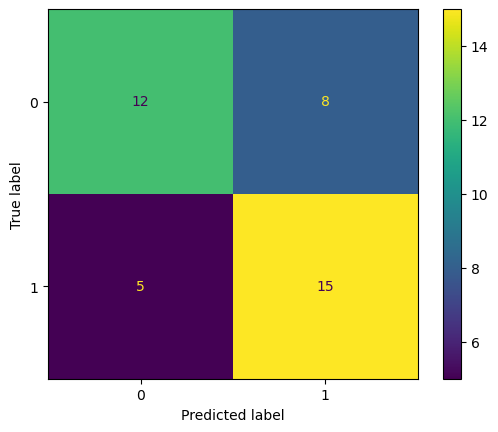

In [19]:
accuracy = accuracy_score(y_test, log_pred)

precision = precision_score(y_test, log_pred)

recall = recall_score(y_test, log_pred)

f1 = f1_score(y_test, log_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

pd.DataFrame({
    "Actual": y_test,
    "Predicted": log_pred
}).to_csv("classification_predictions.csv", index=False)

In [20]:
cluster_features = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

scaled = StandardScaler().fit_transform(cluster_features)

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(scaled)

df["Cluster"] = clusters

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   HighSpender  Cluster  
0            0        2  
1            1        2  
2            0        3  
3            1        2  
4            0        2  


In [21]:
sil_score = silhouette_score(
    scaled,
    clusters
)

print("Silhouette Score:", sil_score)

df.to_csv(
    "clustered_customers.csv",
    index=False
)

Silhouette Score: 0.40846873777345605


In [22]:
comparison = pd.DataFrame({

    "Model":[
        "Ridge Regression",
        "Logistic Regression",
        "KMeans"
    ],

    "Metric":[
        r2,
        accuracy,
        sil_score
    ]

})

comparison

,Model,Metric
0,Ridge Regression,0.018973
1,Logistic Regression,0.675000
2,KMeans,0.408469


In [23]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

pd.DataFrame(grid_ridge.best_params_,index=[0]).to_csv(
    "best_hyperparameters.csv",
    index=False
)

print("Files Saved Successfully")

Files Saved Successfully


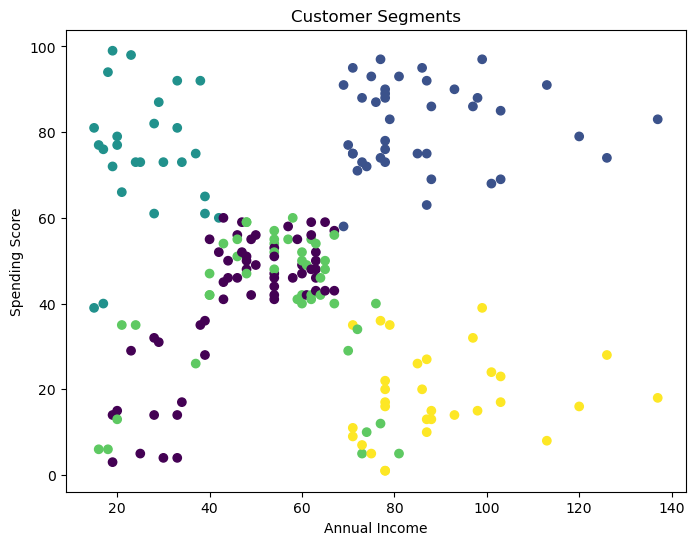

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segments")

plt.show()

In [25]:
print("="*50)
print("TASK 7 COMPLETED")
print("="*50)

print("\nBest Ridge Alpha:",grid_ridge.best_params_)
print("Best Logistic C:",grid_log.best_params_)

print("\nRegression R2:",r2)
print("Classification Accuracy:",accuracy)
print("Silhouette Score:",sil_score)

TASK 7 COMPLETED

Best Ridge Alpha: {'alpha': 10}
Best Logistic C: {'C': 0.1}

Regression R2: 0.01897322999634421
Classification Accuracy: 0.675
Silhouette Score: 0.40846873777345605


In [26]:
import os

print("Generated Files:\n")

for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

Generated Files:

best_hyperparameters.csv
category_summary.csv
classification_predictions.csv
cleaned_dataset.csv
clustered_customers.csv
Mall_Customers (1).csv
model_comparison.csv
regression_predictions.csv
